In [2]:
import os
import sys
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import scipy.sparse
from scipy import optimize
from scipy.stats import norm
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfTransformer
import scanpy as sc
from anndata import AnnData
from muon import atac as ac
import warnings
import pickle

For a portion of this analysis, we will be using some R interoperability, so will we will leverage the rpy2 package to do so.

Thus, we will need to make sure that our R home $PATH is set appropriately prior to importing rpy2, otherwise the kernel will crash 

In [3]:
os.environ['R_HOME'] = '/home/danted/miniforge3/envs/muon/lib/R/'
os.environ['R_HOME']

'/home/danted/miniforge3/envs/muon/lib/R/'

In [4]:
import rpy2.robjects as ro

ro.r('.libPaths("/home/danted/miniforge3/envs/muon/lib/R/library")')

We have some home-brew functions we will import to assist with the analysis

In [5]:
sys.path.append(os.path.expanduser('~/atac_data/misc_scripts/')) #we can use some home-brew functions here
import helper_funcs #some helper functions 
from map_peaks_to_genes import gtf_to_pybedtools, make_bed #functions to convert gtf to pybedtools as well as to make bed files
from vst import vst,gmean_sparse #import a variance stabilization transformation which uses a negative binomial to model counts for scRNA-seq data

In [82]:
sc.settings.verbosity = 3            # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.figdir = "../images"

scanpy==1.10.2 anndata==0.10.8 umap==0.5.9.post2 numpy==1.24.3 scipy==1.14.1 pandas==1.5.3 scikit-learn==1.7.2 statsmodels==0.14.5 igraph==1.0.0 leidenalg==0.11.0 pynndescent==0.5.13


In [7]:
%cd pbmc_10x/

/home/danted/atac_data/pbmc_10x


We are going to continue with the PBMC ATAC-seq dataset we have been working with.

Previously, we preprocessed and normalized the peak data to perform clustering, but now we are going to extend the analysis to evaluate gene activity

We will generate a gene activity matrix, as done previously [here], to count the fragments overlapping promoter and gene body regions of the transcriptome. We can then correlate gene accessibiliy to the global peak clustering, which explicitly uses genomic coordinates. The hope is that we can derive some meaningful differences in accessibility of gene promoters across different cell groups. 

In [7]:
atac = sc.read_h5ad("pbmc_10x_atac_postprocess.h5ad") #read in the previously processed atac data

We will use the TF-IDF transformation for dimensionality reduction to compare to our standard PCA of log-transformed counts which is common for scRNA-seq data. First, we will binarize the counts (1=open, 0=closed) due to the sparsity of the signal. Additionally, biologically we care about whether the chromatin region is "open" or "closed" because as opposed to scRNA-seq where we want to measure expression which is proportional to counts, fragment counts does not necessarily correspond to "more open/closed."

In [17]:
# Binary matrix: 1 = accessible, 0 = closed
X_binary = (atac.layers['raw'] > 0).astype(int)

tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=False)
X_tfidf = tfidf.fit_transform(X_binary)

In [18]:
 #this will generate a linear transformation much like PCA that we can use for further dimensionality reduction
svd = TruncatedSVD(n_components=50, random_state=0, algorithm='arpack')
X_lsi = svd.fit_transform(X_tfidf)

atac.obsm['X_lsi'] = X_lsi[:, 1:50].copy() #copy to original AnnData structure

In [27]:
sc.pp.neighbors(atac, n_neighbors=10, n_pcs=30, use_rep='X_lsi', key_added='X_lsi') #Find nearest-neighbors
sc.tl.leiden(atac, resolution=0.4, neighbors_key='X_lsi') #leiden clustering, can adapt resolution as needed
sc.tl.umap(atac, random_state=0, neighbors_key='X_lsi', min_dist=0.3) #keeping seed consistent and setting min_dist to mimic Seurat

computing neighbors
    finished: added to `.uns['X_lsi']`
    `.obsp['X_lsi_distances']`, distances for each pair of neighbors
    `.obsp['X_lsi_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:15)


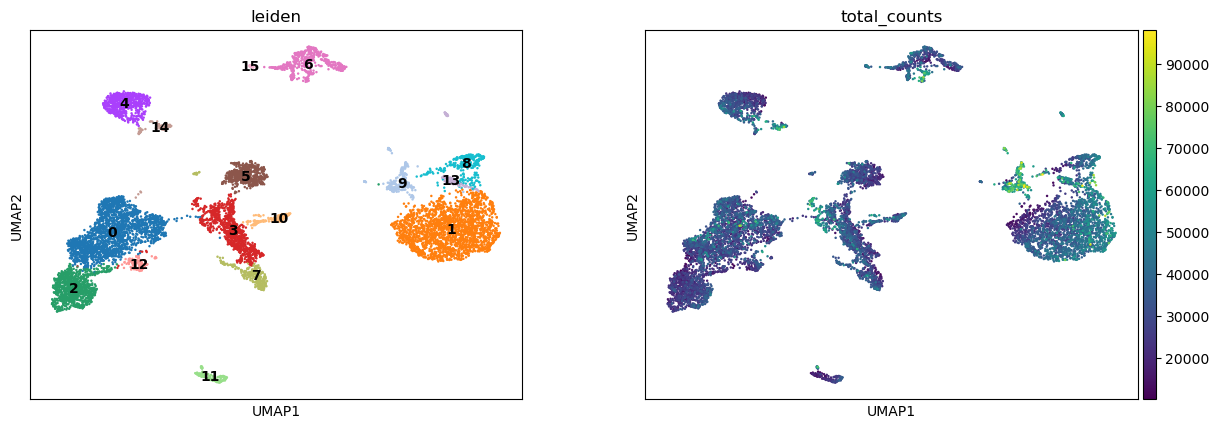

In [28]:
sc.pl.umap(atac, color=['leiden','total_counts'], legend_loc='on data')

In [21]:
atac.write_h5ad('pbmc_10x_atac_postprocess.h5ad') #save for later

In [ ]:
# atac = sc.read_h5ad('pbmc_10x_atac_postprocess.h5ad')

## Generate the gene activity matrix

Perform the following chunks to generate the gene activity matrix. For brevity, the gene activity matrix has already been generated, so we will simply import and create an AnnData structure, but make sure to run if its the first time generating the matrix

In [ ]:
peaks = pd.read_csv(StringIO(make_bed(atac)), sep='\t', header=None).iloc[:, :3]
peaks.columns = ['Chromosome', 'Start', 'End']

tmp = gtf_to_pybedtools(gtf=os.path.expanduser("~/atac_data/refdata-gex-GRCh38-2020-A/genes/genes.gtf"), feature='gene', saveas=True, ondisk=False, chromosomes=peaks.Chromosome.unique().tolist())

# Define the 'features' DataFrame with the specified columns if it's not already defined
features = pd.DataFrame(columns=['Chromosome', 'Start', 'End', 'gene_name'])

rows = []  # Initialize an empty list to collect rows

for i in tmp:
    chrom, start, end, strand, gene_name = i.chrom, i.start, i.end, i.strand, i.name
    rows.append([chrom, start, end, strand, gene_name])  # Append the row to the list

# Convert the list of rows into a DataFrame and append it to the existing 'features' DataFrame
tmp_df = pd.DataFrame(rows, columns=['Chromosome', 'Start', 'End', 'Strand', 'gene_name'])

tmp_df.set_index('gene_name', inplace=True, drop=True)

tmp_df.index.name = ''

In [ ]:
ga = ac.tl.count_fragments_features(atac, features=tmp_df, stranded=True, count_reads=False)

ga.var_names_make_unique()  # make variable names unique

ga.X = ga.X.astype(np.float32) #convert to float32

In [ ]:
undetected_genes = ((ga.X > 0).sum(0) == 0).sum()
print(f"Number of undetected genes: {undetected_genes}")
ga = ga[: , ((ga.X > 0).sum(0) > 0)].copy()

In [ ]:
scipy.sparse.save_npz("gene_activity_mtx.npz", ga.X) #we can save the gene activity matrix for later import

In [ ]:
#save the vars and obs in the AnnData structure as csv files
ga.var.to_csv('gene_activity_mtx_var.csv')
ga.obs.to_csv('gene_activity_mtx_obs.csv')

## Finding informative gene-relevant accessibility using a gene activiy matrix

In [10]:
#If we want to reload the gene activity matrix, we can do so with the following code:

ga_mtx = scipy.sparse.load_npz("gene_activity_mtx.npz")

var = pd.read_csv('gene_activity_mtx_var.csv', index_col=0)
obs = pd.read_csv('gene_activity_mtx_obs.csv', index_col=0)

ga = AnnData(X=ga_mtx, var=var, obs=obs, obsm=atac.obsm, obsp=atac.obsp,uns=atac.uns)

Let's make sure to remove any genes that contain no fragment counts

Much like scRNA-seq, we can normalize and log transform the counts structure. We can store it in a layer to use for later

In [11]:
ga.layers['raw'] = ga.X.copy()
ga.layers['log_norm'] = sc.pp.normalize_total(ga, target_sum=1e4, layer='raw', inplace=False)['X'].copy()
sc.pp.log1p(ga, layer='log_norm')

normalizing counts per cell
    finished (0:00:03)


Now we can calculate the means and variances of genes across cells

In [12]:
ga.var['mean_counts'] = np.array(ga.X.mean(0)).flatten()
ga.var['variance'] = np.var(ga.X.toarray(), 0).flatten()

Let's see how the mean counts and variances fit a poisson and negative binomial model, respectively

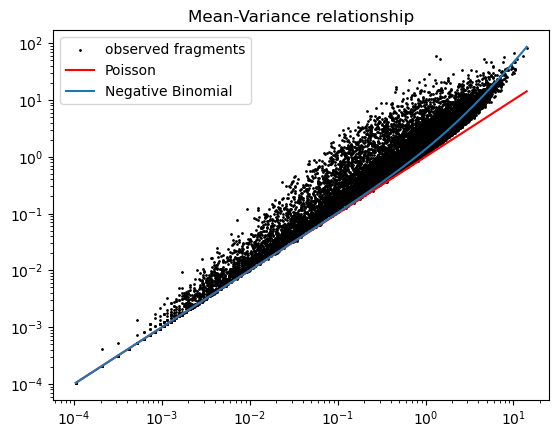

In [37]:
helper_funcs.mean_var_curvefit(ga, ga.var['mean_counts'], ga.var['variance'], nb=True)

As seen above, we can see that the counts structure relatively fits a poisson model, with some overdispersion at higher counts, causing the negative-binomial model to fit.

However, we can see there is some heteroskedasticity of the variance structure, so we will need to benchmark some normalization methods to decide the best way to find informative genes, otherwise we will only select genes with higher expression

Below, we can try to use the variance stabilization transformation (vst) procedure via scTransform in Seurat which works very well to regress out the effects of sequencing depth to find variable features

We can try this method to test whether we can use pearson residuals to find variable features

In [38]:
vst(
    adata = ga,
    n_cells = 5000,
    verbosity = 1,
    n_genes = 2000,
    chunk_size=1000,
    min_cells=10
)

Using 18966 genes
Running Step1
Using negative binomial GLM
Found  106  genes with var <= mean
Found  0  genes with mean < 1e-3
Found  106  poisson genes
Setting theta estimates to Inf
Step1 done. Took 46.0 seconds.
Running Step2
Total outliers: 20
len poisson genes 106
Step2 done. Took 30.0 seconds.
Running Step3
Processing genes 0 to 999
Processing genes 1000 to 1999
Processing genes 2000 to 2999
Processing genes 3000 to 3999
Processing genes 4000 to 4999
Processing genes 5000 to 5999
Processing genes 6000 to 6999
Processing genes 7000 to 7999
Processing genes 8000 to 8999
Processing genes 9000 to 9999
Processing genes 10000 to 10999
Processing genes 11000 to 11999
Processing genes 12000 to 12999
Processing genes 13000 to 13999
Processing genes 14000 to 14999
Processing genes 15000 to 15999
Processing genes 16000 to 16999
Processing genes 17000 to 17999
Processing genes 18000 to 18965
Step3 done. Took 24.0 seconds.


In [39]:
ga.var['gmeans'] = gmean_sparse(ga.X) #calculate geometric mean as opposed to arithmetic mean

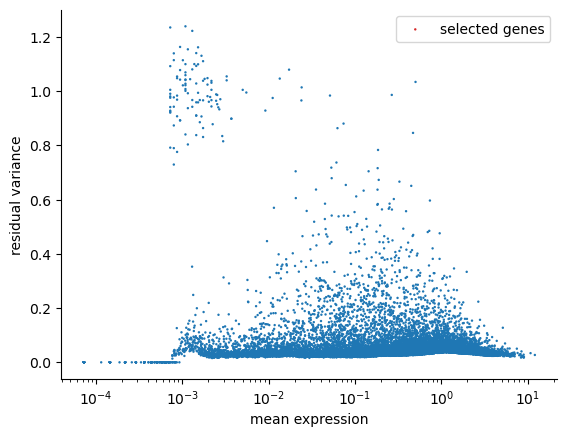

In [40]:
# Create a subplot axis
fig, ax = plt.subplots()

hvgs = ga[:, ((ga.var.highly_variable) & (ga.var.residual_variances > 1.3))].var_names

ax.scatter(
    ga.var["gmeans"], ga.var["residual_variances"], s=3, edgecolor="none"
)
ax.scatter(
    ga.var["gmeans"][hvgs],
    ga.var["residual_variances"][hvgs],
    c="tab:red",
    label="selected genes",
    s=3,
    edgecolor="none",
)
ax.set_xscale("log")
ax.set_xlabel("mean expression")
# ax.set_yscale("log")
ax.set_ylabel("residual variance")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
plt.legend()

Here, it doesn't look like using the vst method is great at identifying variable features

One of the assumptions is that the structure follows a negative binomial model, but we can more simply try using a simplified poisson model to see if this alleviates the issue as it looks like some of the genes with low fragment counts are biasing the residual variances. Additionally, the variances are fairly low across all cell types

Now, we are going to try to calculate the residual variances using following a poisson model, where we will do depth-adjustment of the counts to calculate the residuals. We will then set the overdispersion parameter (theta) to infinity to model poisson mean-variance relationship

In [41]:
#poisson model specified by theta=np.inf
#make sure to use raw counts
df = helper_funcs.residual_vars(ga, theta=np.inf)

Processing peaks 0 to 9999
Processing peaks 10000 to 19170


In [42]:
hvgs_poisson = df.residual_variance.sort_values(ascending=False)[:500].index #take the top 1000 variable features

In [43]:
ga.var['highly_variable_poisson'] = ga.var.index.isin(hvgs_poisson).copy()

ga.var['residual_variance_poisson'] = df.residual_variance.copy()

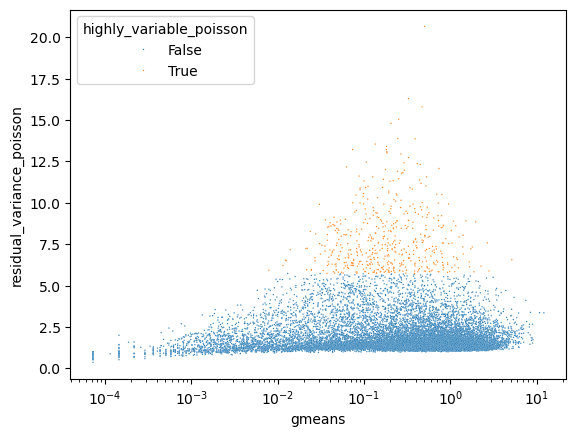

In [44]:
sns.scatterplot(x=ga.var.gmeans, y=ga.var.residual_variance_poisson, hue=ga.var.highly_variable_poisson, s=1)
plt.xscale('log')
plt.show()

This looks slightly better, but we are still only capturing variances of residuals with higher counts. 

As a result, we are going to need a different method to model the counts structure.

If we think about the biology, we are quantifying fragment counts of accessible regions that overlap with gene promoter regions. For genes that are not accessible, we don't expect there to be counts because the Tn5 transposase cannot access those regions. As a result, we expect there to be many dropouts, or zero counts, for those inaccessible regions. Thus, part of the heteroskedasticity may be contributed to an imbalance of zeros in the data, which biologically makes sense.

What if we could actually model the dropouts and quantify the amount of zeros relative to a NULL model? Luckily we can do just that!

As outlined in [this notebook] we can fit the counts structure to generate a sigmoid curve that quantifies the probability of dropouts as a function of expression

In [15]:
damv = helper_funcs.depth_adjusted_mean_var(ga, layer=None) #we will calculate the sequence depth-adjusted variance of the counts data

Processing genes 0 to 999
Processing genes 1000 to 1999
Processing genes 2000 to 2999
Processing genes 3000 to 3999
Processing genes 4000 to 4999
Processing genes 5000 to 5999
Processing genes 6000 to 6999
Processing genes 7000 to 7999
Processing genes 8000 to 8999
Processing genes 9000 to 9999
Processing genes 10000 to 10999
Processing genes 11000 to 11999
Processing genes 12000 to 12999
Processing genes 13000 to 13999
Processing genes 14000 to 14999
Processing genes 15000 to 15999
Processing genes 16000 to 16999
Processing genes 17000 to 17999
Processing genes 18000 to 18999
Processing genes 19000 to 19170


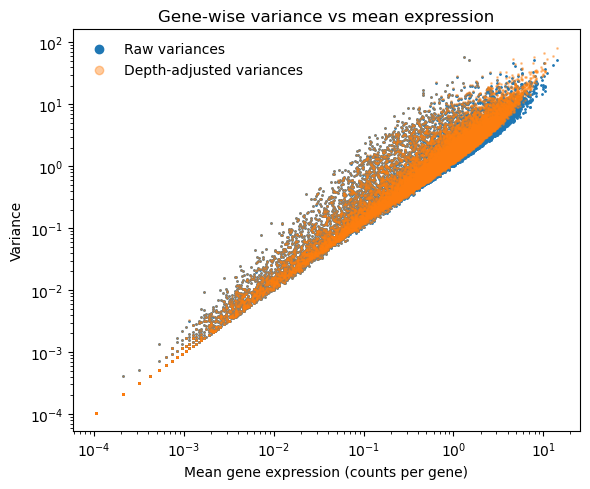

In [80]:
plt.figure(figsize=(6, 5))

plt.scatter(
    ga.var.mean_counts,
    damv['variances'].flatten(),
    s=1,
    label='Raw variances'
)

plt.scatter(
    ga.var.mean_counts,
    ga.var['variance'],
    s=1,
    alpha=0.4,
    label='Depth-adjusted variances'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Mean gene expression (counts per gene)')
plt.ylabel('Variance')

plt.title('Gene-wise variance vs mean expression')

plt.legend(markerscale=6, frameon=False)

plt.tight_layout()
plt.savefig('../images/depth_adj_var_scatter.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()


Above, we can see that we adjusted the overdispersion at higher counts preserves better linearity, suggesting sequencing depth was influencing the overdispersion.

In [24]:
xes = np.array(ga.var.mean_counts) #calculate the mean expression

#find overdispersion parameter using depth adjusted variances
phi, _ = optimize.curve_fit(lambda mu, phi: mu + phi * mu ** 2, xes, damv['variances'].reshape(-1))

droprate_exp = np.zeros(ga.shape[1]) #initialize expected droprate array
droprate_exp_err = np.zeros(ga.shape[1]) #initialize expected droprate standard error array

xes_var = np.squeeze(damv['variances']) #get depth-adjusted variances

for i in range(ga.shape[1]):
        mu_i = xes[i] #extract mean for each gene in the array
        if xes_var[i] <= mu_i or mu_i <= 0.01:
            droprate_exp[i] = helper_funcs.NB_drop_prob(mu_i, phi=0) #gene-wise expected droprate for poisson model
        else:
            droprate_exp[i] = helper_funcs.NB_drop_prob(mu_i, phi) #gene-wise expected droprate for negative binomial model

droprate_exp_err = np.sqrt(droprate_exp * (1 - droprate_exp) / ga.shape[0]) #standard error for expectation

djs = np.array(ga.shape[0] - (ga.X > 0).sum(0)).flatten() #calculate the total dropouts, or zeros, per gene across all cells

droprate_obs = djs / ga.shape[0] #observed droprate 
droprate_obs_err = np.sqrt(droprate_obs * (1 - droprate_obs) / ga.shape[0]) #standard error for observed

combined_err = np.sqrt(droprate_exp_err**2 + droprate_obs_err**2) #combined error
diff = droprate_obs - droprate_exp #find differences
Zed = diff / combined_err #calculate z-score

p_value = (1 - norm.cdf(Zed)) #extract p-values
    
p_value_df = pd.DataFrame({'p_val':p_value,
                        'inv_diff':droprate_obs - droprate_exp,
                        'Zed':Zed,
                        'droprate_expected':droprate_exp,
                        'droprate_observed':droprate_obs,
                        'mean_expression':xes,}, index=pd.array(ga.var_names))
p_value_df = p_value_df.sort_values(by=['p_val', 'Zed'], ascending=[True,False]) #sort for benjamini-hochberg correction

# Adjust p-values for multiple testing to reduce false discoveries
reject, q_val, _, _ = multipletests(np.array(p_value_df['p_val']), method="fdr_bh")
p_value_df['q_val'] = q_val #add q-values to dataframe
            

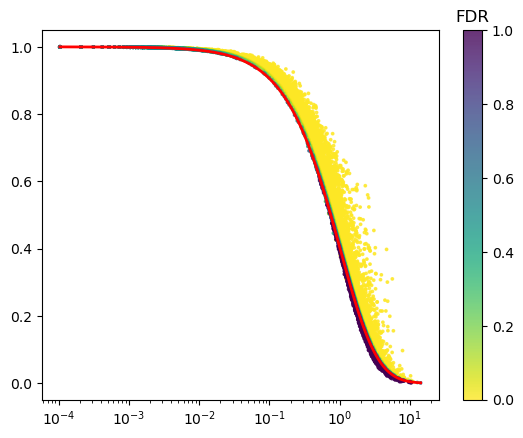

In [25]:
mm = np.logspace(min(np.log10(xes)), max(np.log10(xes)), num=ga.shape[1])
plt.scatter(p_value_df.mean_expression, p_value_df.droprate_observed, c=p_value_df.q_val, cmap='viridis_r', alpha=0.8, s=3)
plt.plot(mm, helper_funcs.NB_drop_prob(mm, phi), c='r', lw=2)
plt.colorbar()
plt.gcf().axes
plt.gcf().axes[1].set(title=f'FDR')
plt.xscale('log')

This looks promising; we can see that we can find significant genes that are shifted to the right of the curve signifying they have more dropouts relative to the NULL sigmoid curve.

These genes are worth investigating to see if their counts are different across clusters!

Let's first extract the top 1000 genes for brevity, but we can also choose to filter based on q-value

In [26]:
top_genes = p_value_df.nsmallest(1000, 'q_val').index.tolist() #get the top 1000 highly variable genes

p_value_df['highly_variable'] =  p_value_df.index.isin(top_genes) #rename as highly variable

running Leiden clustering
    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


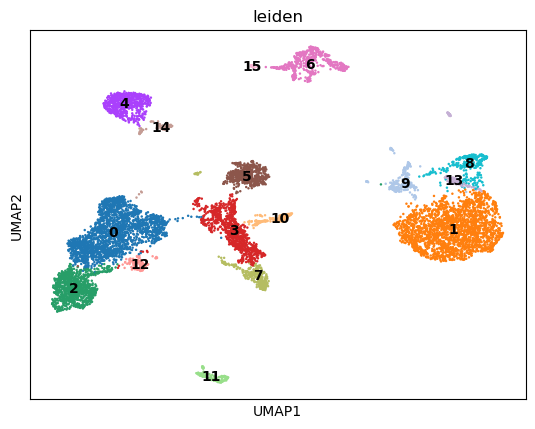

In [83]:
sc.tl.leiden(ga, resolution=0.4, neighbors_key='X_lsi', random_state=0) #leiden clustering, can adapt resolution as needed
sc.pl.umap(ga, color='leiden', legend_loc='on data', save='_leiden_clustering.png')

Now how do we know which genes to futher refine for? We need a high-throughput way to investigate cluster relevant genes without manually checking each one. Additionally, this is ATAC-Seq data, so we may want to find some interesting regions of genes that don't always show up in scRNA-seq data, such as transcription factors

Without knowing which genes to select for a-priori, we can use logistic regression!

Logistic regression are useful in classification tasks where we have a categorial classifier (i.e., cluster) and we want to find how an independent variable (such as fragment counts) can predict cluster assignment using a sigmoid (expit) function to generate probabilities of assignment. Genes with a good classification power can lead us to some insightful biology and can reveal cluster specific patterns.

Below we have a home-brew function to:

- Filter the gene activity AnnData object by the selected variable genes
- Split the data into training and test datasets
- Scale the data to 0 mean and unit variance
- Generate the logistic regression using a One vs Rest Classifier
- Evaluate classification via ROC and confusion matrix


Finished subsetting by genes
splitting into training and test datasets
Finished normalizing training data


/home/danted/miniforge3/envs/muon/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/danted/miniforge3/envs/muon/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/danted/miniforge3/envs/muon/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/danted/miniforge3/envs/muon/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/danted/miniforge3/envs/muon/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dant

Finished logistic regression fitting on training data
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1113
           1       0.93      0.98      0.96      1114
          10       0.92      0.84      0.88        80
          11       0.97      0.97      0.97        74
          12       0.85      0.52      0.65        67
          13       0.82      0.88      0.85        51
          14       0.70      0.34      0.46        41
          15       0.90      0.69      0.78        13
           2       0.89      0.89      0.89       526
           3       0.84      0.84      0.84       425
           4       0.94      0.97      0.95       316
           5       0.93      0.92      0.92       271
           6       0.97      0.97      0.97       251
           7       0.86      0.82      0.84       156
           8       0.96      0.85      0.90       147
           9       0.70      0.39      0.50       147

    accuracy              

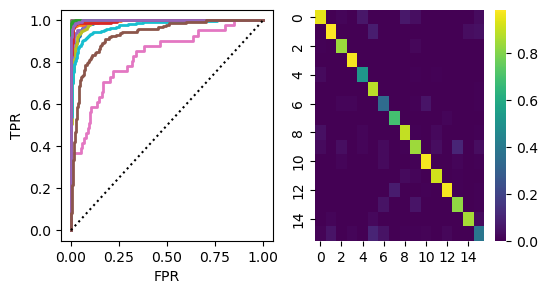

In [57]:
# sc.tl.leiden(adata, resolution = 0.2)
result = helper_funcs.lr_classifier(ga,
                       hvgs_list=top_genes,
                       layer='log_norm',
                       cluster_key='leiden', 
                       solver= 'sag',
                       max_iter= 1000, 
                       train_size=0.5)

Looking at the above classification metrics, we can see that the classifier worked quite well at being able to use the fragment counts to predict cluster assignment. This gives us some more confidence that we can reliably use the logistic regression method to find some biologically relevant genes

After addressing that we can indeed use a logistic regression using the top 500 variable genes we selected for, we can filter the original gene matrix using the same 500 genes

We will then use the log transformed counts to convert to 0 mean and unit variance to fit the entire dataset to a SGD (stochastic gradient descent) classifier for computational efficiency as well as to leverage the various regularization parameters (i.e., L1, L2, elastic-net)

In [28]:
counts = ga[:, ga.var_names.isin(top_genes)].copy() #subset gene activity matrix by top 500 genes
counts.X = counts.layers['log_norm'].copy() #use the log normalized counts
X_ = counts.X.toarray() #has to be dense array
y_ = counts.obs.leiden #let's use the leiden clustering
Z_ = np.array(np.log10(counts.obs.total_counts)).reshape(-1,1) #also use counts as a covariate

scaler_X = StandardScaler() # preserve sparsity
X_train = scaler_X.fit_transform(X_) #fit to training data

scaler_Z = StandardScaler()
Z_train = scaler_Z.fit_transform(Z_)

X_aug = np.hstack([X_train, Z_train])

In [ ]:
#create the classifier
classifier = OneVsRestClassifier(SGDClassifier(loss='log_loss',
                           max_iter=100,
                           n_jobs=-1,
                           random_state=0,
                          ))

#grid search for best values
param_grid = {
    'estimator__penalty': ['l1', 'l2', 'elasticnet'],
    'estimator__l1_ratio': [0.1, 0.25, 0.5, 0.75]  # 0->pure L2, 1->pure L1, others mixed
}

# cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# run grid search
gs = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=2,
    return_train_score=True
)

In [ ]:
gs.fit(X_aug, y_) #fit the data

In [ ]:
#look at the best scores
print(gs.best_params_)
print(gs.best_score_)

After generating the classifier, we will then run on the entire dataset. Typically, the output will be weights that are associated with each classification groups that we can rank by. However, the downside to this is that the weights provide no statistics about the magnitude of their importance. As a result, we a need a way to assess the reliability of the output.

One thing we can do is rank by permutation importance, which is an agnostic method to measure the predictive power of a model via random shuffling. For example, this will answer the question, what happens to the model when we randomly shuffle the counts? If there is a sugnificant drop in performance, this suggests the feature is more important for classification. This principle is similar to how GSEA uses a permutation-based significance testing. We can perform as many iterations at the cost of time, so we will use only 10 random permutations per class for now.

In [29]:
#create the classifier
sgd = SGDClassifier(loss='log_loss',
                           max_iter=100,
                           n_jobs=-1,
                           random_state=0,
                           penalty='elasticnet',
                           l1_ratio=0.5
                          )

# Initialize an empty dictionary to store results
leiden_features = {}

for class_label in y_.unique():
    # Create binary labels: 1 for the class of interest, 0 for all others
    binary_y = (y_ == class_label).astype(int)
    
    # Train the classifier on this binary task
    sgd.fit(X_aug, binary_y)
    
    # Compute permutation importance for this class
    result_pi = permutation_importance(sgd, X_aug, binary_y, n_repeats=10, random_state=0, n_jobs=-1)
    
    print(f'finished permutations for cluster {class_label}')
    
    # Store the result in the dictionary
    leiden_features[class_label] = result_pi.importances_mean

finished permutations for cluster 1
finished permutations for cluster 2
finished permutations for cluster 6
finished permutations for cluster 0
finished permutations for cluster 3
finished permutations for cluster 4
finished permutations for cluster 5
finished permutations for cluster 7
finished permutations for cluster 10
finished permutations for cluster 8
finished permutations for cluster 12
finished permutations for cluster 14


/home/danted/miniforge3/envs/muon/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


finished permutations for cluster 9
finished permutations for cluster 11
finished permutations for cluster 15
finished permutations for cluster 13


In [30]:
sgd.features = counts.var.index.append(pd.Index(["total_counts"])) #use gene names

In [31]:
leiden_features_ = {k: v[:-1] for k, v in leiden_features.items()} #we used counts as a covariate so we exclude that variable

In [32]:
lr_res = pd.DataFrame.from_dict(leiden_features_, orient='index', columns=sgd.features[:-1])

In [33]:
#extract the top 5 markers from each cluster
top_markers = lr_res.assign(cluster=lr_res.index.astype('category')) \
.melt(id_vars=['cluster'], var_name='gene', value_name='weight') \
.sort_values('weight', ascending=False) \
.groupby('cluster') \
.head(5) \
.sort_values(['cluster','weight'], ascending=[True,False])

In [34]:
ga.obs['leiden'] = ga.obs['leiden'].astype('category')

In [35]:
#pseudobulking the data due to sparsity in signal
col = ga.obs.leiden.unique()
pbs = []
for i in col:
    #group each cell by leiden label
    sub = ga[ga.obs['leiden'] == i]
    rep_adata = sc.AnnData(X = sub.X.mean(0).reshape(1,-1),
                           var = sub.var[[]])
    rep_adata.obs_names = [i]
    
    pbs.append(rep_adata)

pb = sc.concat(pbs).to_df() #concat to a single dataframe
pb = pb.apply(lambda x: (x - x.mean()) / x.std(), axis=0) #zero mean and unit variance
pb = pb.loc[:, pb.columns.isin(top_markers.drop_duplicates(subset='gene').gene.tolist())] #subset by top markers
pb.columns = pb.columns.str.split('|').str[-1]

In [36]:
# pb: rows = cell types / clusters, columns = genes
# We want to cluster columns (cell types), keep genes in fixed order

# Compute pairwise distance between columns (cell types)
dist = pdist(pb.values, metric='euclidean')  # or 'correlation', etc.

# Perform hierarchical clustering
Z = linkage(dist, method='average')  # or 'ward', 'complete', etc.

# Get the column order from the dendrogram
col_order = leaves_list(Z)

top_markers['cluster'] = pd.Categorical(top_markers['cluster'],
                                        categories=pb.iloc[col_order, :].index.tolist(), 
                                        ordered=True
                                       )
top_markers = top_markers.sort_values(by=['cluster','weight'], ascending=[True,False])

# Reorder the DataFrame columns
pb = pb.loc[:, top_markers.drop_duplicates(subset='gene').gene.tolist()]  # rows reordered according to clustering

In [47]:
top_markers[top_markers['cluster'] == '2']

,cluster,gene,weight
7841,2,PLCL1,0.016508
7201,2,CD8A,0.013931
11041,2,INPP4B,0.011520
7553,2,ZEB2,0.011520
2337,2,PRR5L,0.011113


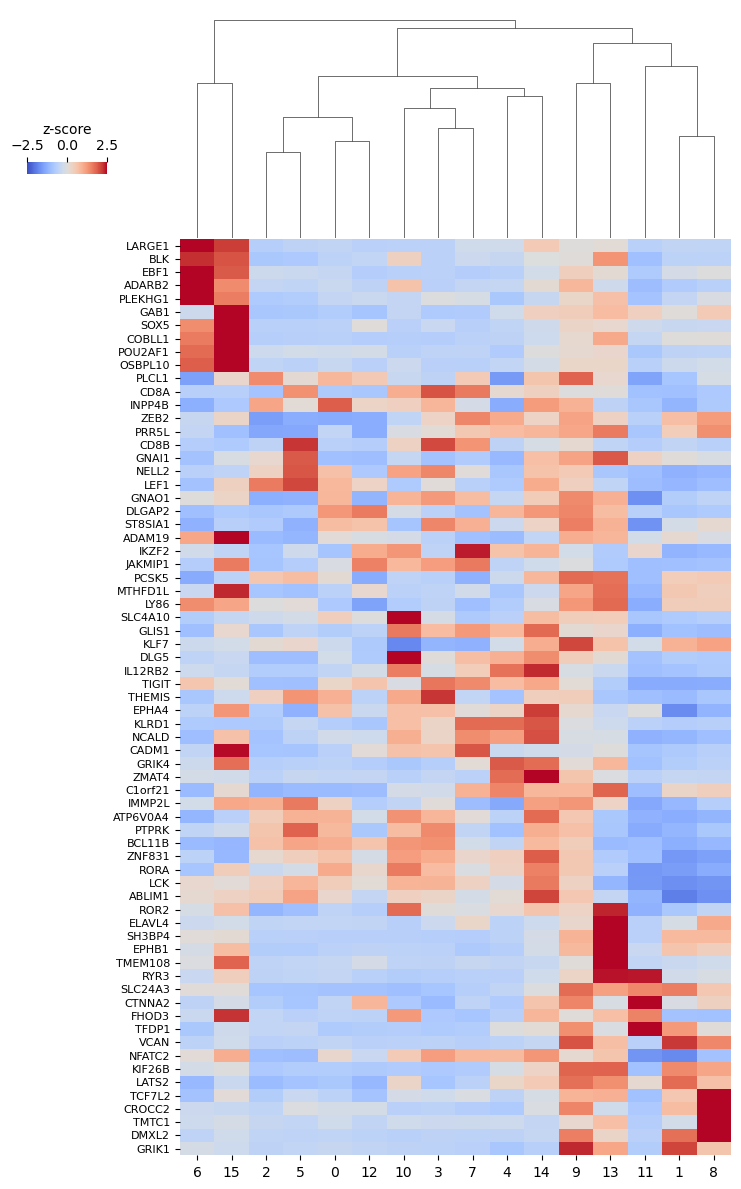

In [81]:
#plot the data using seaborn clustermap
g = sns.clustermap(pb.T,
                   cmap = sns.color_palette("coolwarm", as_cmap=True), 
                   cbar_pos=(0.0, 0.85, 0.1, 0.01), 
                   figsize=(8,12),
                   cbar_kws={"orientation": "horizontal", "label": "z-score"},
                   yticklabels=True,
                   row_cluster=False,
                   col_cluster=True,
                   col_linkage=Z,
                   vmin=-2.5,
                   vmax=2.5
                  )

g.ax_heatmap.yaxis.set_ticks_position('left')
# Adjust the font size of y-axis labels
for label in g.ax_heatmap.get_yticklabels():
    label.set_fontsize(8)  # Set to a smaller font size
    
# Remove the row and column dendrograms
g.ax_row_dendrogram.set_visible(False)
# g.ax_col_dendrogram.set_visible(False)

# Move the colorbar ticks and label to the top
g.cax.xaxis.set_ticks_position('top')
g.cax.xaxis.set_label_position('top')


plt.savefig('../images/d2c_clustermap.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0.15)
plt.show()

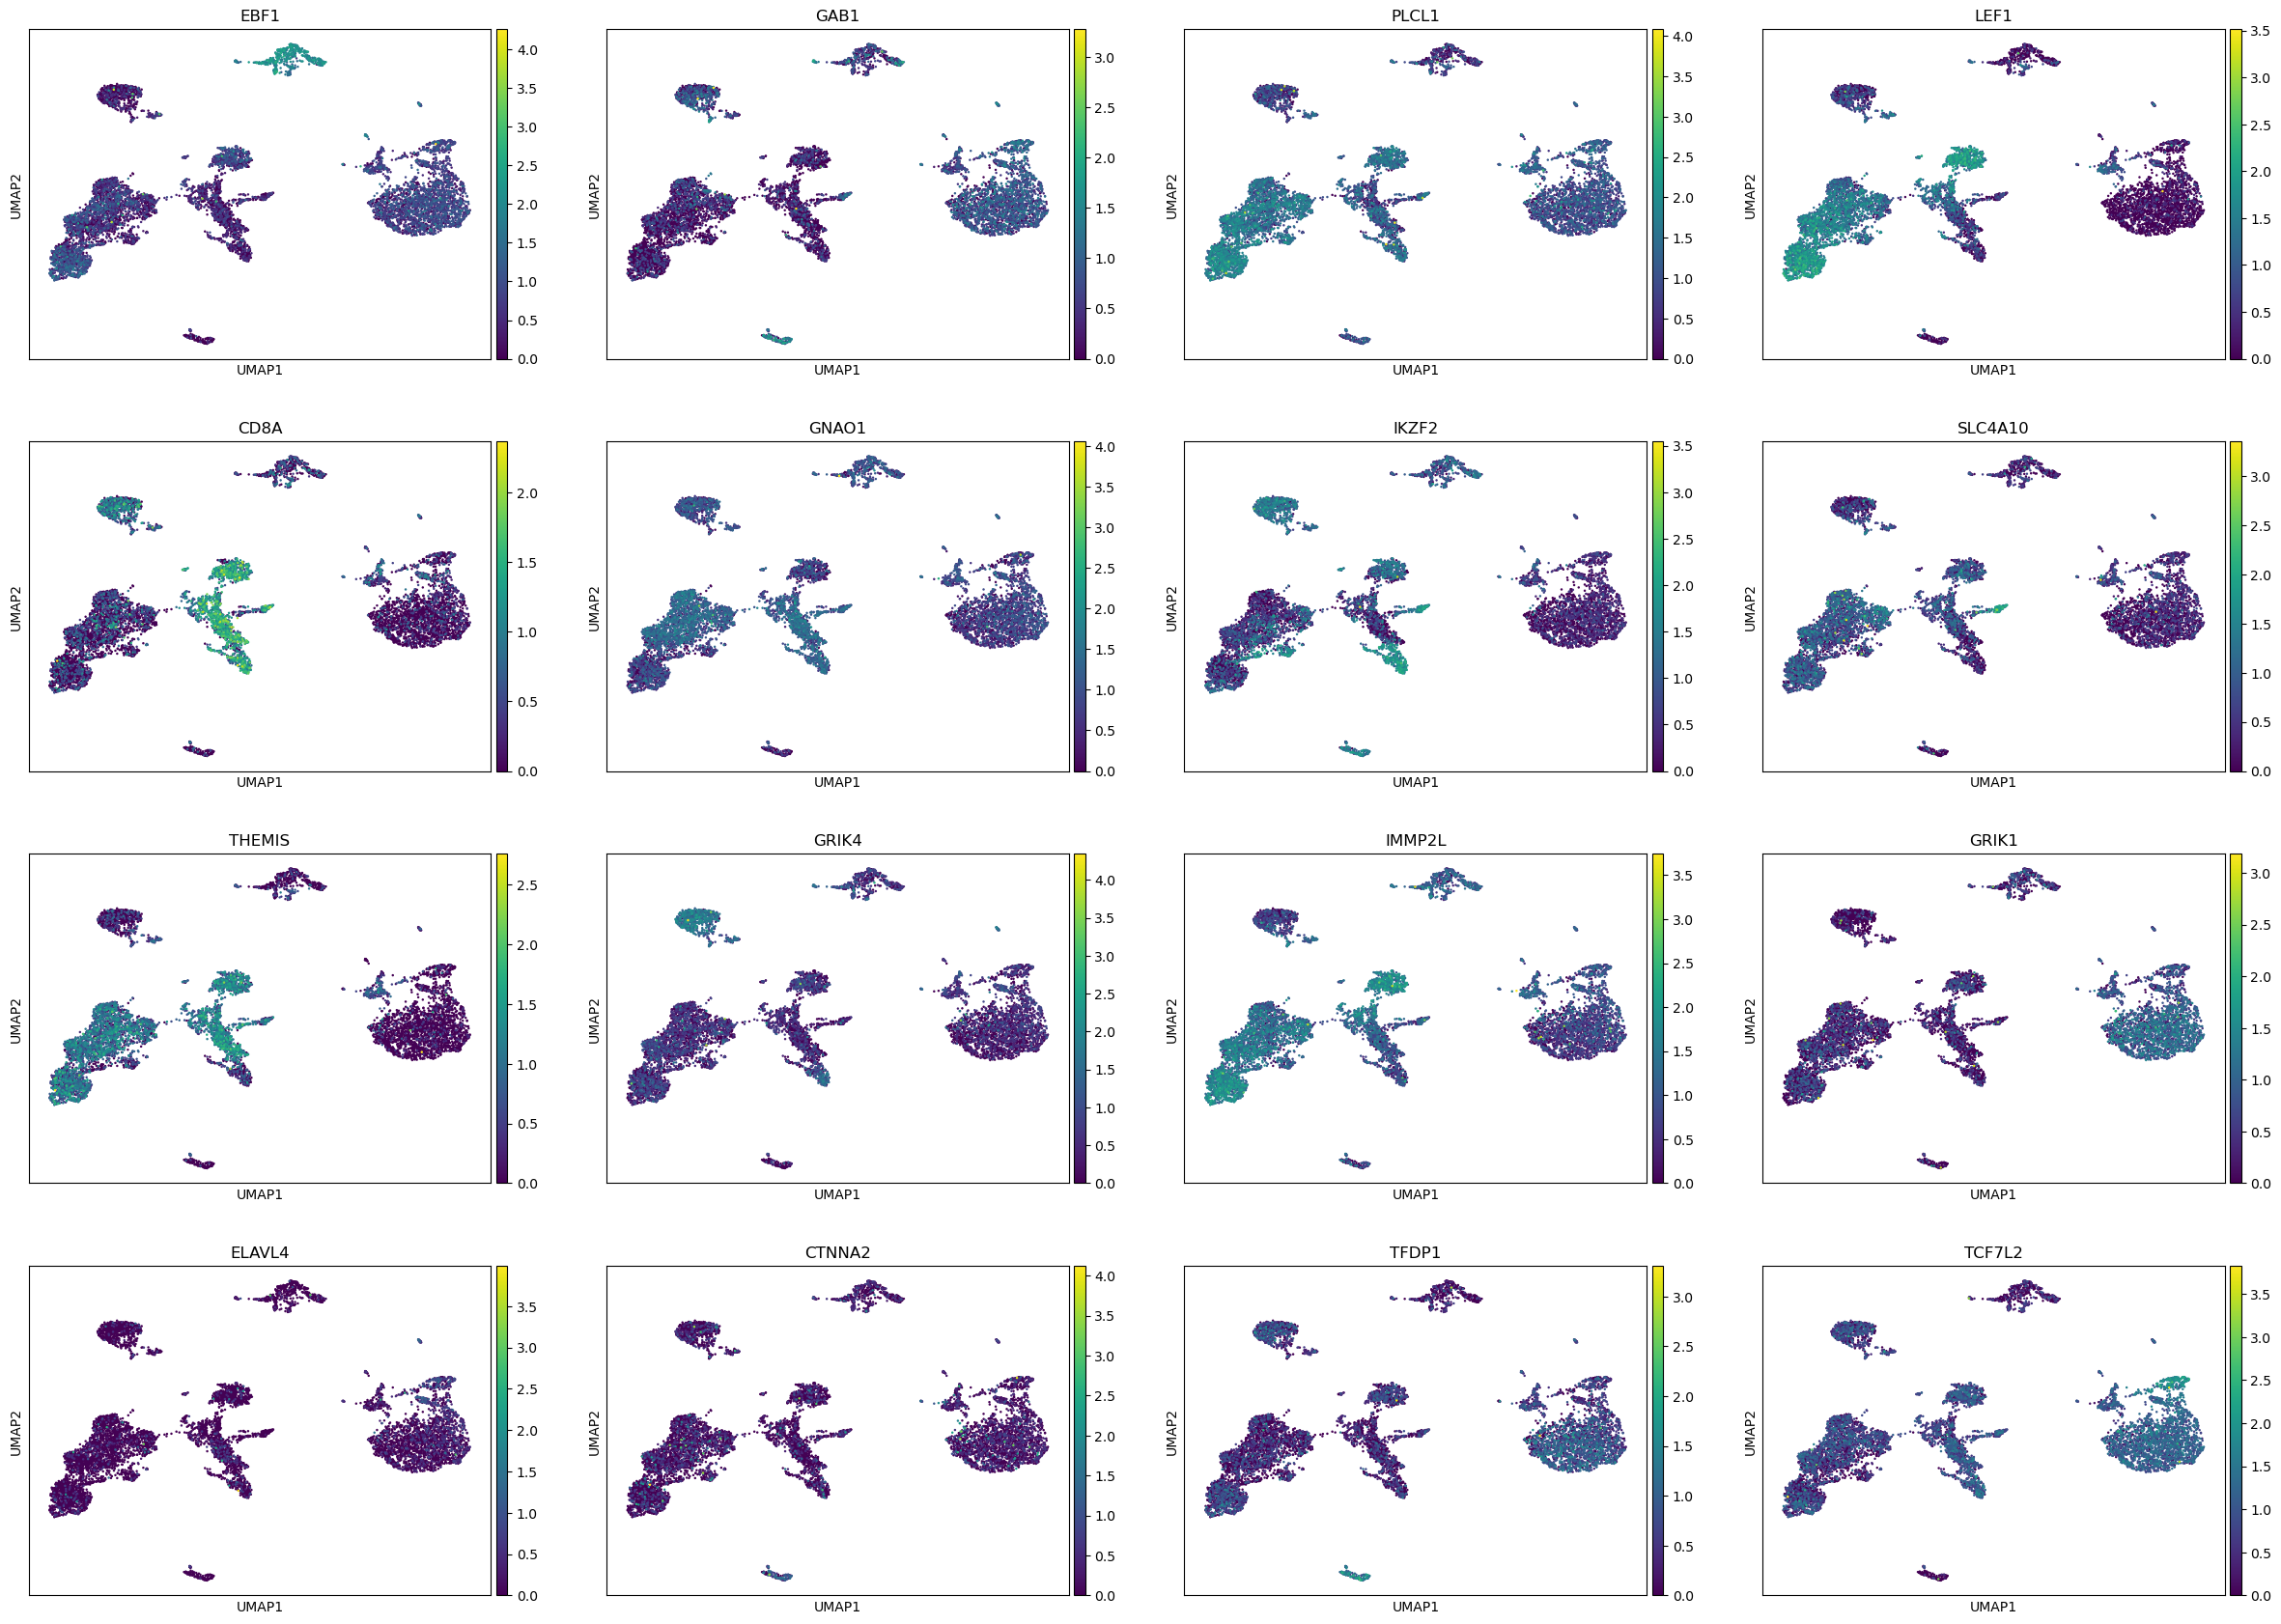

In [ ]:
sc.pl.umap(adata=ga, color=["EBF1","GAB1","PLCL1","LEF1","CD8A",'GNAO1','IKZF2','SLC4A10','THEMIS','GRIK4','IMMP2L','GRIK1','ELAVL4','CTNNA2','TFDP1','TCF7L2'], 
           legend_loc="on data", ncols=4, layer='log_norm', save='feature_plot.png')
